In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

print("Imports done!")

Imports done!


In [2]:
class ScratchCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(ScratchCNN, self).__init__()

        # 3 convolutional layers
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        # Max pooling
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Flatten → Linear
        self.fc1 = nn.Linear(128 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 224 → 112
        x = self.pool(F.relu(self.conv2(x)))   # 112 → 56
        x = self.pool(F.relu(self.conv3(x)))   #  56 → 28

        x = x.view(x.size(0), -1)             # flatten: [batch, 128*28*28]

        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model_scratch = ScratchCNN(num_classes=38)
print(model_scratch)

ScratchCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=100352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=38, bias=True)
)


In [3]:
total = sum(p.numel() for p in model_scratch.parameters())
print(f"Scratch CNN total parameters: {total:,}")
print(f"\nFor comparison:")
print(f"EfficientNet-B0 total parameters: 5,288,548")
print(f"EfficientNet trainable (frozen):       48,678")
print(f"\nScratch CNN is training ALL {total:,} params from zero")
print(f"EfficientNet only trained 48,678 params on top of pretrained knowledge")

Scratch CNN total parameters: 25,793,382

For comparison:
EfficientNet-B0 total parameters: 5,288,548
EfficientNet trainable (frozen):       48,678

Scratch CNN is training ALL 25,793,382 params from zero
EfficientNet only trained 48,678 params on top of pretrained knowledge


In [4]:
import os, json

os.makedirs("/root/.kaggle", exist_ok=True)
kaggle_credentials = {
    "username": "ishwarirautray",
    "key": "KGAT_c42443df0152824059832271ff3ac0e1"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:21<00:00, 103MB/s] 

Dataset ready!


In [5]:
from torchvision import datasets

# Load dataset just to grab one image path
base_path = "plantvillage/plantvillage dataset/color"
dataset = datasets.ImageFolder(base_path)

# Get path of first image
img_path, label_idx = dataset.samples[0]
label_name = dataset.classes[label_idx]

print(f"Image: {img_path}")
print(f"True label: {label_name}")

# Load and preprocess
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img = Image.open(img_path).convert("RGB")
img_tensor = transform(img).unsqueeze(0)  # add batch dimension → [1, 3, 224, 224]

print(f"\nInput tensor shape: {img_tensor.shape}")

# Forward pass through scratch CNN
model_scratch.eval()
with torch.no_grad():
    output = model_scratch(img_tensor)

predicted_idx = output.argmax(dim=1).item()
predicted_name = dataset.classes[predicted_idx]
confidence = torch.softmax(output, dim=1).max().item() * 100

print(f"\nPredicted: {predicted_name}")
print(f"Confidence: {confidence:.2f}%")
print(f"\n(Weights are random — prediction is meaningless until trained)")

Image: plantvillage/plantvillage dataset/color/Apple___Apple_scab/00075aa8-d81a-4184-8541-b692b78d398a___FREC_Scab 3335.JPG
True label: Apple___Apple_scab

Input tensor shape: torch.Size([1, 3, 224, 224])

Predicted: Raspberry___healthy
Confidence: 2.86%

(Weights are random — prediction is meaningless until trained)


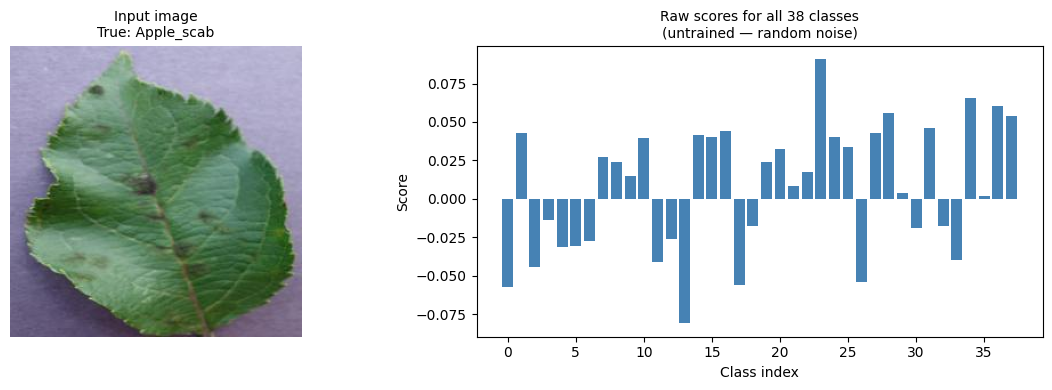


Highest score at class index: 23 (Raspberry___healthy)
True class index: 0 (Apple___Apple_scab)
Match: False


In [6]:
# Show the image + raw output scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: the actual image
ax1.imshow(img)
ax1.set_title(f"Input image\nTrue: {label_name.split('___')[1]}", fontsize=10)
ax1.axis("off")

# Right: raw output scores for all 38 classes
scores = output.squeeze().numpy()
ax2.bar(range(38), scores, color="steelblue")
ax2.set_title("Raw scores for all 38 classes\n(untrained — random noise)", fontsize=10)
ax2.set_xlabel("Class index")
ax2.set_ylabel("Score")

plt.tight_layout()
plt.show()

print(f"\nHighest score at class index: {scores.argmax()} ({dataset.classes[scores.argmax()]})")
print(f"True class index: {label_idx} ({label_name})")
print(f"Match: {scores.argmax() == label_idx}")